In [ ]:
#| default_exp models.dl_forecaster

# Deep Learning Forecaster (`dl_forecaster`)

> Unified, model-agnostic PyTorch Deep Learning forecasting framework supporting LSTM, GRU, RNN, Transformer, and MLP models.


The `dl_forecaster` module bridges state-of-the-art PyTorch deep learning architectures with `peshbeen`'s unified, model-agnostic forecasting workflow. It implements the exact same `.fit(df)` and `.forecast(H)` pipeline established in `ml_forecaster`, featuring:

- **Modular PyTorch Neural Blocks**: Standalone, clean `nn.Module` classes (`LSTMModel`, `GRUModel`, `RNNModel`, `TransformerModel`, `MLPModel`).
- **Scikit-Learn Compatible Estimators**: `TorchRegressor`, `LSTMRegressor`, `GRURegressor`, `TransformerRegressor`, `MLPRegressor` providing `.fit(X, y)` and `.predict(X)` with automated mini-batch `DataLoader`, Apple Silicon MPS/CUDA/CPU device management, early stopping, and AdamW optimization.
- **Automated Feature & Target Scaling**: Built-in `feature_scaler` and `target_scaler` (defaulting to `StandardScaler()`) to ensure numerical stability and fast gradient descent convergence.
- **Full Feature Engineering & Stationarity Pipeline**: Lags, lag transforms, Box-Cox variance stabilization, linear/piecewise/ETS de-trending, ordinary & seasonal differencing, and categorical feature encoding.
- **Diagnostic & Model Selection Support**: In-sample fitted values, recursive multi-step forecasting with exact inverse transformations, rolling-window cross-validation, and full compatibility with `optuna_tune`.

In [ ]:
#| export
from __future__ import annotations
from typing import List, Dict, Optional, Callable, Tuple, Any, Union, Type
import numpy as np
import pandas as pd
import copy
import warnings
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
from torch.utils.data import TensorDataset, DataLoader
from sklearn.base import BaseEstimator, RegressorMixin
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.compose import ColumnTransformer
from statsmodels.tsa.holtwinters import ExponentialSmoothing

from peshbeen.model_selection import SplitTimeSeries
from peshbeen.statstools import lr_trend_model, forecast_trend
from peshbeen.transformations import (
    box_cox_transform, back_box_cox_transform,
    rolling_quantile, expanding_mean, expanding_std, expanding_quantile
)
from peshbeen.helpers import seasonal_diff, undiff_ts, invert_seasonal_diff

In [ ]:
#| export
class PositionalEncoding(nn.Module):
    """
    Sinusoidal positional encoding for Transformer-based time series architectures.
    Injects temporal order information into sequence token embeddings.
    """
    def __init__(self, d_model: int, max_len: int = 5000):
        super().__init__()
        pe = torch.zeros(max_len, d_model)
        position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
        div_term = torch.exp(torch.arange(0, d_model, 2).float() * (-np.log(10000.0) / d_model))
        pe[:, 0::2] = torch.sin(position * div_term)
        pe[:, 1::2] = torch.cos(position * div_term)
        self.register_buffer('pe', pe.unsqueeze(0))

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Add positional encoding up to input sequence length
        return x + self.pe[:, :x.size(1)]


class LSTMModel(nn.Module):
    """
    Multi-layer Long Short-Term Memory (LSTM) network for time series forecasting.

    Parameters
    ----------
    input_size : int
        Number of input feature dimensions (e.g. sequence length or feature count).
    hidden_size : int, default 64
        Number of hidden units in each recurrent layer.
    num_layers : int, default 2
        Number of stacked recurrent layers.
    dropout : float, default 0.0
        Dropout probability between stacked recurrent layers and dense head.
    bidirectional : bool, default False
        Whether to use a bidirectional recurrent network.
    output_size : int, default 1
        Number of predicted target values (1 for univariate point forecast).
    """
    def __init__(
        self,
        input_size: int,
        hidden_size: int = 64,
        num_layers: int = 2,
        dropout: float = 0.0,
        bidirectional: bool = False,
        output_size: int = 1
    ):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        # Input projection layer to embed 1D sequential steps into hidden_size
        self.input_proj = nn.Linear(1, hidden_size)

        # Recurrent backbone
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional
        )

        fc_in = hidden_size * 2 if bidirectional else hidden_size
        self.fc = nn.Sequential(
            nn.Linear(fc_in, max(hidden_size // 2, 4)),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(max(hidden_size // 2, 4), output_size)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Support 2D (batch_size, n_features) and 3D (batch_size, seq_len, 1)
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        h = self.input_proj(x)
        out, _ = self.lstm(h)
        # Extract representation from the last sequence step
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden).squeeze(-1)


class GRUModel(nn.Module):
    """
    Multi-layer Gated Recurrent Unit (GRU) network for time series forecasting.

    Parameters
    ----------
    input_size : int
        Number of input feature dimensions.
    hidden_size : int, default 64
        Number of hidden units in each recurrent layer.
    num_layers : int, default 2
        Number of stacked recurrent layers.
    dropout : float, default 0.0
        Dropout probability between stacked recurrent layers and dense head.
    bidirectional : bool, default False
        Whether to use a bidirectional recurrent network.
    output_size : int, default 1
        Number of predicted target values.
    """
    def __init__(
        self,
        input_size: int,
        hidden_size: int = 64,
        num_layers: int = 2,
        dropout: float = 0.0,
        bidirectional: bool = False,
        output_size: int = 1
    ):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers
        self.bidirectional = bidirectional

        self.input_proj = nn.Linear(1, hidden_size)
        self.gru = nn.GRU(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True,
            bidirectional=bidirectional
        )
        fc_in = hidden_size * 2 if bidirectional else hidden_size
        self.fc = nn.Sequential(
            nn.Linear(fc_in, max(hidden_size // 2, 4)),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(max(hidden_size // 2, 4), output_size)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        h = self.input_proj(x)
        out, _ = self.gru(h)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden).squeeze(-1)


class RNNModel(nn.Module):
    """
    Standard Elman Recurrent Neural Network (RNN) module for time series forecasting.

    Parameters
    ----------
    input_size : int
        Number of input feature dimensions.
    hidden_size : int, default 64
        Number of hidden units in each recurrent layer.
    num_layers : int, default 1
        Number of stacked recurrent layers.
    nonlinearity : str, default 'tanh'
        Non-linearity to use ('tanh' or 'relu').
    dropout : float, default 0.0
        Dropout probability.
    output_size : int, default 1
        Number of predicted target values.
    """
    def __init__(
        self,
        input_size: int,
        hidden_size: int = 64,
        num_layers: int = 1,
        nonlinearity: str = 'tanh',
        dropout: float = 0.0,
        output_size: int = 1
    ):
        super().__init__()
        self.input_size = input_size
        self.hidden_size = hidden_size
        self.num_layers = num_layers

        self.input_proj = nn.Linear(1, hidden_size)
        self.rnn = nn.RNN(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            nonlinearity=nonlinearity,
            dropout=dropout if num_layers > 1 else 0.0,
            batch_first=True
        )
        self.fc = nn.Sequential(
            nn.Linear(hidden_size, max(hidden_size // 2, 4)),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(max(hidden_size // 2, 4), output_size)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        h = self.input_proj(x)
        out, _ = self.rnn(h)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden).squeeze(-1)


class TransformerModel(nn.Module):
    """
    Transformer Encoder network with Multi-Head Self-Attention for time series forecasting.

    Parameters
    ----------
    input_size : int
        Number of input feature dimensions.
    d_model : int, default 64
        Expected feature dimension for transformer input and attention layers.
    nhead : int, default 4
        Number of attention heads (d_model must be divisible by nhead).
    num_layers : int, default 2
        Number of TransformerEncoderLayer sub-layers.
    dim_feedforward : int, default 128
        Dimension of the feedforward network model in TransformerEncoderLayer.
    dropout : float, default 0.1
        Dropout probability.
    output_size : int, default 1
        Number of predicted target values.
    """
    def __init__(
        self,
        input_size: int,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.1,
        output_size: int = 1
    ):
        super().__init__()
        self.input_size = input_size
        self.d_model = d_model
        self.input_proj = nn.Linear(1, d_model)
        self.pos_encoder = PositionalEncoding(d_model)
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model,
            nhead=nhead,
            dim_feedforward=dim_feedforward,
            dropout=dropout,
            batch_first=True
        )
        self.transformer_encoder = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        self.fc = nn.Sequential(
            nn.Linear(d_model, max(d_model // 2, 4)),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(max(d_model // 2, 4), output_size)
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 2:
            x = x.unsqueeze(-1)
        h = self.input_proj(x)
        h = self.pos_encoder(h)
        out = self.transformer_encoder(h)
        last_hidden = out[:, -1, :]
        return self.fc(last_hidden).squeeze(-1)


class MLPModel(nn.Module):
    """
    Multi-Layer Perceptron (feedforward neural network) for time series regression.

    Parameters
    ----------
    input_size : int
        Total number of input features.
    hidden_layers : list of int, default [64, 32]
        Layer sizes for the hidden dense blocks.
    activation : str, default 'relu'
        Activation function ('relu', 'gelu', or 'tanh').
    dropout : float, default 0.0
        Dropout probability after each hidden layer.
    output_size : int, default 1
        Number of output values.
    """
    def __init__(
        self,
        input_size: int,
        hidden_layers: List[int] = [64, 32],
        activation: str = 'relu',
        dropout: float = 0.0,
        output_size: int = 1
    ):
        super().__init__()
        layers = []
        in_dim = input_size
        act_fn = nn.ReLU if activation.lower() == 'relu' else (nn.GELU if activation.lower() == 'gelu' else nn.Tanh)
        for h_dim in hidden_layers:
            layers.append(nn.Linear(in_dim, h_dim))
            layers.append(act_fn())
            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            in_dim = h_dim
        layers.append(nn.Linear(in_dim, output_size))
        self.net = nn.Sequential(*layers)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if x.dim() == 3 and x.size(-1) == 1:
            x = x.squeeze(-1)
        return self.net(x).squeeze(-1)

In [ ]:
#| export
MODEL_REGISTRY: Dict[str, Type[nn.Module]] = {
    'lstm': LSTMModel,
    'gru': GRUModel,
    'rnn': RNNModel,
    'transformer': TransformerModel,
    'mlp': MLPModel
}


class TorchRegressor(BaseEstimator, RegressorMixin):
    """
    Scikit-learn compatible regression estimator for PyTorch deep learning models.

    Provides `.fit(X, y)` and `.predict(X)` interfaces, mini-batch DataLoader generation,
    automated device dispatching (CUDA, Apple Silicon MPS, CPU), early stopping, and
    seamless compatibility with `peshbeen.model_selection.optuna_tune`.
    """
    def __init__(
        self,
        model: Union[str, nn.Module, Type[nn.Module]] = 'lstm',
        model_params: Optional[Dict[str, Any]] = None,
        lr: float = 1e-3,
        weight_decay: float = 1e-5,
        epochs: int = 100,
        batch_size: int = 32,
        optimizer: str = 'adamw',
        loss: str = 'mse',
        patience: int = 10,
        validation_split: float = 0.1,
        random_state: Optional[int] = 42,
        device: Optional[str] = None,
        verbose: bool = False
    ):
        self.model = model
        self.model_params = model_params or {}
        self.lr = lr
        self.weight_decay = weight_decay
        self.epochs = epochs
        self.batch_size = batch_size
        self.optimizer = optimizer
        self.loss = loss
        self.patience = patience
        self.validation_split = validation_split
        self.random_state = random_state
        self.device = device
        self.verbose = verbose

    def _get_device(self) -> torch.device:
        """Automatically resolve the best available execution device (CUDA > MPS > CPU)."""
        if self.device is not None:
            return torch.device(self.device)
        if torch.cuda.is_available():
            return torch.device("cuda")
        if hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
            return torch.device("mps")
        return torch.device("cpu")

    def _build_model(self, input_size: int) -> nn.Module:
        """Instantiate the underlying neural network module with the given input size."""
        params = dict(self.model_params)
        params["input_size"] = input_size
        if isinstance(self.model, str):
            model_key = self.model.lower()
            if model_key not in MODEL_REGISTRY:
                raise ValueError(f"Unknown model '{self.model}'. Supported: {list(MODEL_REGISTRY.keys())}")
            return MODEL_REGISTRY[model_key](**params)
        elif isinstance(self.model, type) and issubclass(self.model, nn.Module):
            return self.model(**params)
        elif isinstance(self.model, nn.Module):
            return copy.deepcopy(self.model)
        else:
            raise TypeError("model must be a model string name, an nn.Module class, or an nn.Module instance.")

    def fit(self, X: Union[pd.DataFrame, np.ndarray], y: Union[pd.Series, np.ndarray]) -> "TorchRegressor":
        """Fit the PyTorch model on input features X and target y."""
        if self.random_state is not None:
            torch.manual_seed(self.random_state)
            np.random.seed(self.random_state)

        X_arr = X.values if isinstance(X, pd.DataFrame) else np.asarray(X, dtype=np.float32)
        y_arr = y.values if isinstance(y, (pd.Series, pd.DataFrame)) else np.asarray(y, dtype=np.float32)

        self.n_features_in_ = X_arr.shape[1]
        self.device_ = self._get_device()
        self.network_ = self._build_model(self.n_features_in_).to(self.device_)

        n_samples = len(X_arr)
        if self.validation_split > 0 and n_samples > 10:
            val_size = max(1, int(n_samples * self.validation_split))
            train_idx = np.arange(n_samples - val_size)
            val_idx = np.arange(n_samples - val_size, n_samples)
            X_tr, y_tr = X_arr[train_idx], y_arr[train_idx]
            X_val, y_val = X_arr[val_idx], y_arr[val_idx]
        else:
            X_tr, y_tr = X_arr, y_arr
            X_val, y_val = None, None

        tr_ds = TensorDataset(torch.tensor(X_tr, dtype=torch.float32), torch.tensor(y_tr, dtype=torch.float32))
        tr_loader = DataLoader(tr_ds, batch_size=min(self.batch_size, len(tr_ds)), shuffle=True)

        if X_val is not None:
            val_x_t = torch.tensor(X_val, dtype=torch.float32).to(self.device_)
            val_y_t = torch.tensor(y_val, dtype=torch.float32).to(self.device_)

        # Criterion selection
        if self.loss.lower() == 'huber':
            criterion = nn.HuberLoss()
        elif self.loss.lower() in ('l1', 'mae'):
            criterion = nn.L1Loss()
        else:
            criterion = nn.MSELoss()

        # Optimizer selection
        if self.optimizer.lower() == 'adam':
            opt = torch.optim.Adam(self.network_.parameters(), lr=self.lr, weight_decay=self.weight_decay)
        elif self.optimizer.lower() == 'sgd':
            opt = torch.optim.SGD(self.network_.parameters(), lr=self.lr, weight_decay=self.weight_decay, momentum=0.9)
        else:
            opt = torch.optim.AdamW(self.network_.parameters(), lr=self.lr, weight_decay=self.weight_decay)

        best_loss = float('inf')
        best_weights = None
        no_improve_count = 0

        self.network_.train()
        for epoch in range(self.epochs):
            for batch_x, batch_y in tr_loader:
                batch_x, batch_y = batch_x.to(self.device_), batch_y.to(self.device_)
                opt.zero_grad()
                pred = self.network_(batch_x)
                loss_val = criterion(pred, batch_y)
                loss_val.backward()
                opt.step()

            # Validation tracking for early stopping
            if X_val is not None:
                self.network_.eval()
                with torch.no_grad():
                    val_pred = self.network_(val_x_t)
                    cur_val_loss = criterion(val_pred, val_y_t).item()
                self.network_.train()

                if cur_val_loss < best_loss:
                    best_loss = cur_val_loss
                    best_weights = copy.deepcopy(self.network_.state_dict())
                    no_improve_count = 0
                else:
                    no_improve_count += 1
                    if no_improve_count >= self.patience:
                        break

        if best_weights is not None:
            self.network_.load_state_dict(best_weights)
        self.network_.eval()
        return self

    def predict(self, X: Union[pd.DataFrame, np.ndarray]) -> np.ndarray:
        """Generate predictions for input features X."""
        if not hasattr(self, "network_"):
            raise ValueError("TorchRegressor is not fitted yet. Call .fit() before .predict().")
        X_arr = X.values if isinstance(X, pd.DataFrame) else np.asarray(X, dtype=np.float32)
        x_t = torch.tensor(X_arr, dtype=torch.float32).to(self.device_)
        self.network_.eval()
        with torch.no_grad():
            preds = self.network_(x_t).cpu().numpy()
        return np.atleast_1d(preds).flatten()

    def get_params(self, deep: bool = True) -> Dict[str, Any]:
        """Return estimator parameters for Scikit-Learn and Optuna compatibility."""
        params = {
            "model": self.model,
            "model_params": self.model_params,
            "lr": self.lr,
            "weight_decay": self.weight_decay,
            "epochs": self.epochs,
            "batch_size": self.batch_size,
            "optimizer": self.optimizer,
            "loss": self.loss,
            "patience": self.patience,
            "validation_split": self.validation_split,
            "random_state": self.random_state,
            "device": self.device,
            "verbose": self.verbose
        }
        if self.model_params:
            for k, v in self.model_params.items():
                params[k] = v
        return params

    def set_params(self, **params) -> "TorchRegressor":
        """Set estimator parameters dynamically during hyperparameter tuning."""
        for k, v in params.items():
            if hasattr(self, k):
                setattr(self, k, v)
            else:
                self.model_params[k] = v
        return self


class LSTMRegressor(TorchRegressor):
    """
    Scikit-learn compatible LSTM Regressor ready for use in ml_forecaster and dl_forecaster.
    """
    def __init__(
        self,
        hidden_size: int = 64,
        num_layers: int = 2,
        dropout: float = 0.0,
        bidirectional: bool = False,
        lr: float = 1e-3,
        weight_decay: float = 1e-5,
        epochs: int = 100,
        batch_size: int = 32,
        optimizer: str = 'adamw',
        loss: str = 'mse',
        patience: int = 10,
        validation_split: float = 0.1,
        random_state: Optional[int] = 42,
        device: Optional[str] = None,
        verbose: bool = False
    ):
        super().__init__(
            model='lstm',
            model_params={'hidden_size': hidden_size, 'num_layers': num_layers,
                          'dropout': dropout, 'bidirectional': bidirectional},
            lr=lr, weight_decay=weight_decay, epochs=epochs, batch_size=batch_size,
            optimizer=optimizer, loss=loss, patience=patience, validation_split=validation_split,
            random_state=random_state, device=device, verbose=verbose
        )


class GRURegressor(TorchRegressor):
    """
    Scikit-learn compatible GRU Regressor ready for use in ml_forecaster and dl_forecaster.
    """
    def __init__(
        self,
        hidden_size: int = 64,
        num_layers: int = 2,
        dropout: float = 0.0,
        bidirectional: bool = False,
        lr: float = 1e-3,
        weight_decay: float = 1e-5,
        epochs: int = 100,
        batch_size: int = 32,
        optimizer: str = 'adamw',
        loss: str = 'mse',
        patience: int = 10,
        validation_split: float = 0.1,
        random_state: Optional[int] = 42,
        device: Optional[str] = None,
        verbose: bool = False
    ):
        super().__init__(
            model='gru',
            model_params={'hidden_size': hidden_size, 'num_layers': num_layers,
                          'dropout': dropout, 'bidirectional': bidirectional},
            lr=lr, weight_decay=weight_decay, epochs=epochs, batch_size=batch_size,
            optimizer=optimizer, loss=loss, patience=patience, validation_split=validation_split,
            random_state=random_state, device=device, verbose=verbose
        )


class RNNRegressor(TorchRegressor):
    """
    Scikit-learn compatible Elman RNN Regressor ready for use in ml_forecaster and dl_forecaster.
    """
    def __init__(
        self,
        hidden_size: int = 64,
        num_layers: int = 1,
        nonlinearity: str = 'tanh',
        dropout: float = 0.0,
        lr: float = 1e-3,
        weight_decay: float = 1e-5,
        epochs: int = 100,
        batch_size: int = 32,
        optimizer: str = 'adamw',
        loss: str = 'mse',
        patience: int = 10,
        validation_split: float = 0.1,
        random_state: Optional[int] = 42,
        device: Optional[str] = None,
        verbose: bool = False
    ):
        super().__init__(
            model='rnn',
            model_params={'hidden_size': hidden_size, 'num_layers': num_layers,
                          'nonlinearity': nonlinearity, 'dropout': dropout},
            lr=lr, weight_decay=weight_decay, epochs=epochs, batch_size=batch_size,
            optimizer=optimizer, loss=loss, patience=patience, validation_split=validation_split,
            random_state=random_state, device=device, verbose=verbose
        )


class TransformerRegressor(TorchRegressor):
    """
    Scikit-learn compatible Transformer Encoder Regressor for time series forecasting.
    """
    def __init__(
        self,
        d_model: int = 64,
        nhead: int = 4,
        num_layers: int = 2,
        dim_feedforward: int = 128,
        dropout: float = 0.1,
        lr: float = 1e-3,
        weight_decay: float = 1e-5,
        epochs: int = 100,
        batch_size: int = 32,
        optimizer: str = 'adamw',
        loss: str = 'mse',
        patience: int = 10,
        validation_split: float = 0.1,
        random_state: Optional[int] = 42,
        device: Optional[str] = None,
        verbose: bool = False
    ):
        super().__init__(
            model='transformer',
            model_params={'d_model': d_model, 'nhead': nhead, 'num_layers': num_layers,
                          'dim_feedforward': dim_feedforward, 'dropout': dropout},
            lr=lr, weight_decay=weight_decay, epochs=epochs, batch_size=batch_size,
            optimizer=optimizer, loss=loss, patience=patience, validation_split=validation_split,
            random_state=random_state, device=device, verbose=verbose
        )


class MLPRegressor(TorchRegressor):
    """
    Scikit-learn compatible Multi-Layer Perceptron (feedforward) Regressor.
    """
    def __init__(
        self,
        hidden_layers: List[int] = [64, 32],
        activation: str = 'relu',
        dropout: float = 0.0,
        lr: float = 1e-3,
        weight_decay: float = 1e-5,
        epochs: int = 100,
        batch_size: int = 32,
        optimizer: str = 'adamw',
        loss: str = 'mse',
        patience: int = 10,
        validation_split: float = 0.1,
        random_state: Optional[int] = 42,
        device: Optional[str] = None,
        verbose: bool = False
    ):
        super().__init__(
            model='mlp',
            model_params={'hidden_layers': hidden_layers, 'activation': activation, 'dropout': dropout},
            lr=lr, weight_decay=weight_decay, epochs=epochs, batch_size=batch_size,
            optimizer=optimizer, loss=loss, patience=patience, validation_split=validation_split,
            random_state=random_state, device=device, verbose=verbose
        )

In [ ]:
#| export
class dl_forecaster:
    """
    Deep Learning Forecaster for Time Series.

    Seamlessly wraps PyTorch neural networks (LSTM, GRU, Transformer, RNN, MLP) in
    peshbeen's unified forecasting workflow. Automatically performs lag feature generation,
    lag transforms, Box-Cox variance stabilization, trend de-trending, differencing,
    and robust feature & target scaling.
    """
    def __init__(
        self,
        model: Union[str, Any] = 'lstm',
        target_col: str = 'target',
        lags: Optional[Union[int, List[int]]] = None,
        lag_transform: Optional[list] = None,
        difference: Optional[int] = None,
        seasonal_diff: Optional[int] = None,
        trend: Optional[str] = None,
        pol_degree: int = 1,
        ets_params: Optional[Dict[str, Any]] = None,
        change_points: Optional[List[int]] = None,
        box_cox: Union[bool, float, int] = False,
        box_cox_biasadj: bool = False,
        feature_scaler: Optional[Any] = StandardScaler(),
        target_scaler: Optional[Any] = StandardScaler(),
        cat_variables: Optional[List[str]] = None,
        categorical_encoder: Optional[Any] = None,
        model_params: Optional[Dict[str, Any]] = None
    ) -> None:
        """
        Initialize the dl_forecaster.

        Parameters
        ----------
        model : str or estimator object, default 'lstm'
            Either a model name ('lstm', 'gru', 'rnn', 'transformer', 'mlp'), an instantiated
            TorchRegressor / LSTMRegressor, or a custom PyTorch nn.Module.
        target_col : str
            Name of the target variable column in the input DataFrame.
        lags : int or list of int, optional
            Lags to generate as features. If int, lags 1 to N are created.
        lag_transform : list of callable, optional
            List of lag-transformation functions (e.g. rolling_mean, expanding_std).
        difference : int, optional
            Order of ordinary differencing.
        seasonal_diff : int, optional
            Seasonal period for seasonal differencing.
        trend : str, optional
            Trend strategy: 'linear' or 'ets'.
        pol_degree : int, default 1
            Polynomial degree for linear trend fitting.
        ets_params : dict, optional
            Parameters for ExponentialSmoothing trend model.
        change_points : list of int, optional
            Indices of change points for piecewise linear trend fitting.
        box_cox : bool or float or int, default False
            Whether to apply Box-Cox transformation (or specific lambda).
        box_cox_biasadj : bool, default False
            Apply bias adjustment when inverting Box-Cox.
        feature_scaler : object or None, default StandardScaler()
            Scikit-Learn compatible transformer to normalize feature inputs (crucial for deep learning).
        target_scaler : object or None, default StandardScaler()
            Scikit-Learn compatible transformer to normalize target variable (prevents exploding gradients).
        cat_variables : list of str, optional
            List of categorical column names.
        categorical_encoder : object, optional
            Encoder object (e.g. OneHotEncoder, TargetEncoder).
        model_params : dict, optional
            Dictionary of hyperparameters passed to the neural network when model is a string.
        """
        if isinstance(model, str):
            self.model = TorchRegressor(model=model, model_params=model_params or {})
        elif isinstance(model, nn.Module) or (isinstance(model, type) and issubclass(model, nn.Module)):
            self.model = TorchRegressor(model=model, model_params=model_params or {})
        else:
            self.model = model

        self.model_name = self.model.__class__.__name__
        self.target_col = target_col
        self.feature_scaler = copy.deepcopy(feature_scaler) if feature_scaler is not None else None
        self.target_scaler = copy.deepcopy(target_scaler) if target_scaler is not None else None
        self.cat_variables = cat_variables
        self.cat_encoder = categorical_encoder
        self.cps = change_points
        self.pol = pol_degree

        if isinstance(box_cox, bool):
            self.box_cox = box_cox
            self.lamda = None
        elif isinstance(box_cox, (float, int)):
            self.box_cox = True
            self.lamda = box_cox
        self.biasadj = box_cox_biasadj
        self.difference = difference
        self.season_diff = seasonal_diff
        self.lag_transform = lag_transform

        # ── trend configuration ───────────────────────────────────────────────
        self.trend = trend
        if self.trend == "ets":
            self.ets_model = {}
            self.ets_fit = {}
            if ets_params is not None:
                constructor_params = ["trend","damped_trend", "seasonal","seasonal_periods","initialization_method",
                                      "initial_level","initial_trend", "initial_seasonal","bounds","dates","freq","missing"]
                fit_params = ["optimized","smoothing_level","smoothing_trend","smoothing_seasonal","damping_trend",
                              "remove_bias","start_params","method","minimize_kwargs","use_brute"]
                for param in constructor_params:
                    if param in ets_params:
                        self.ets_model[param] = ets_params[param]
                for param in fit_params:
                    if param in ets_params:
                        self.ets_fit[param] = ets_params[param]

        # ── lags ──────────────────────────────────────────────────────────────
        if lags is None:
            self.n_lag = None
        elif isinstance(lags, int):
            self.n_lag = list(range(1, lags + 1))
        elif isinstance(lags, list):
            if not all(isinstance(l, int) for l in lags):
                raise TypeError("lags list must contain only integers.")
            self.n_lag = lags
        else:
            raise TypeError("lags must be an int or a list of ints.")

    # ─────────────────────────────────────────────────────────────────────────
    # DATA PREPARATION
    # ─────────────────────────────────────────────────────────────────────────
    def data_prep(self, df: pd.DataFrame) -> pd.DataFrame:
        """Prepare the time series DataFrame with all feature engineering and stationarity transformations."""
        dfc = df.copy()
        if self.cat_variables is not None:
            dfc = self.create_encoded_features(dfc)

        if self.target_col not in dfc.columns:
            return dfc.dropna()

        self.orig_target = dfc[self.target_col].values

        # ── Box-Cox Transformation ────────────────────────────────────────────
        if self.box_cox:
            self.is_zero = np.any(np.array(dfc[self.target_col]) < 1)
            self.trans_data, self.lamda = box_cox_transform(
                x=dfc[self.target_col], shift=self.is_zero, box_cox_lmda=self.lamda
            )
            dfc[self.target_col] = self.trans_data

        # ── Trend Removal ─────────────────────────────────────────────────────
        if self.trend is not None:
            self.len = len(df)
            self.target_orig = dfc[self.target_col].copy()
            if self.trend == "linear":
                if self.cps is not None:
                    self.trend_vals, self.lr_model, self.X_trend = lr_trend_model(
                        dfc[self.target_col], degree=self.pol,
                        breakpoints=self.cps, type='piecewise'
                    )
                else:
                    self.trend_vals, self.lr_model, self.X_trend = lr_trend_model(
                        dfc[self.target_col], degree=self.pol
                    )
            elif self.trend == "ets":
                self.ets_model_fit = ExponentialSmoothing(
                    dfc[self.target_col], **self.ets_model
                ).fit(**self.ets_fit)
                self.trend_vals = self.ets_model_fit.fittedvalues.values
            else:
                raise ValueError(f"Unknown trend type '{self.trend}'. Use 'linear' or 'ets'.")
            dfc[self.target_col] = dfc[self.target_col] - self.trend_vals

        # ── Ordinary Differencing ─────────────────────────────────────────────
        if self.difference is not None or self.season_diff is not None:
            self.orig = dfc[self.target_col].tolist()
            if self.difference is not None:
                dfc[self.target_col] = np.diff(
                    dfc[self.target_col], n=self.difference,
                    prepend=np.repeat(np.nan, self.difference)
                )

        # ── Seasonal Differencing ─────────────────────────────────────────────
            if self.season_diff is not None:
                self.orig_d = dfc[self.target_col].tolist()
                dfc[self.target_col] = seasonal_diff(dfc[self.target_col], self.season_diff)

        # ── Lag Features ──────────────────────────────────────────────────────
        if self.n_lag is not None:
            for lag in self.n_lag:
                dfc[f"{self.target_col}_lag_{lag}"] = dfc[self.target_col].shift(lag)

        # ── Lag Transforms ────────────────────────────────────────────────────
        if self.lag_transform is not None:
            for func in self.lag_transform:
                if isinstance(func, (expanding_std, expanding_mean)):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}"] = func(dfc[self.target_col])
                elif isinstance(func, expanding_quantile):
                    dfc[f"{func.__class__.__name__}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                elif isinstance(func, rolling_quantile):
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}_q{func.quantile}"] = func(dfc[self.target_col])
                else:
                    dfc[f"{func.__class__.__name__}_{func.window_size}_shift_{func.shift}"] = func(dfc[self.target_col])

        return dfc.dropna()

    def create_encoded_features(self, df: pd.DataFrame) -> pd.DataFrame:
        """Encode categorical variables with column transformers."""
        for col in self.cat_variables:
            df[col] = df[col].astype('category')
        if self.cat_encoder is not None:
            if self.target_col in df.columns:
                num_cols = [c for c in df.columns if c not in self.cat_variables + [self.target_col]]
                self.preprocess = ColumnTransformer(
                    transformers=[("cat", self.cat_encoder, self.cat_variables), ("num", "passthrough", num_cols)],
                    remainder="drop",
                    verbose_feature_names_out=False
                ).set_output(transform="pandas")
                X_train = self.preprocess.fit_transform(df.drop(columns=[self.target_col]), y=df[self.target_col])
                return pd.concat([df[[self.target_col]], X_train], axis=1)
            else:
                return self.preprocess.transform(df)
        return df

    # ─────────────────────────────────────────────────────────────────────────
    # FIT
    # ─────────────────────────────────────────────────────────────────────────
    def fit(self, df: pd.DataFrame) -> "dl_forecaster":
        """
        Fit the deep learning model to the training DataFrame after data preparation and normalization.
        """
        model_df = self.data_prep(df)
        self.X = model_df.drop(columns=[self.target_col])
        self.y = model_df[self.target_col]

        # Feature Scaling (Crucial for Neural Networks)
        if self.feature_scaler is not None:
            X_train = pd.DataFrame(
                self.feature_scaler.fit_transform(self.X),
                columns=self.X.columns, index=self.X.index
            )
        else:
            X_train = self.X

        # Target Scaling (Prevents exploding/vanishing gradients)
        if self.target_scaler is not None:
            y_train = pd.Series(
                self.target_scaler.fit_transform(self.y.values.reshape(-1, 1)).flatten(),
                index=self.y.index, name=self.target_col
            )
        else:
            y_train = self.y

        self.model_fit = self.model.fit(X_train, y_train)
        return self

    # ─────────────────────────────────────────────────────────────────────────
    # PREDICT IN SAMPLE
    # ─────────────────────────────────────────────────────────────────────────
    def predict_in_sample(self) -> np.ndarray:
        """Generate in-sample fitted values and residuals on the original series scale."""
        if not hasattr(self, "model_fit"):
            raise ValueError("Model has not been fitted yet. Call .fit() before predict_in_sample().")

        X_eval = pd.DataFrame(self.feature_scaler.transform(self.X), columns=self.X.columns) if self.feature_scaler is not None else self.X
        preds_scaled = self.model_fit.predict(X_eval)

        # Invert target scaling
        if self.target_scaler is not None:
            fitted_values = self.target_scaler.inverse_transform(preds_scaled.reshape(-1, 1)).flatten()
        else:
            fitted_values = preds_scaled

        fit_len = len(fitted_values)
        self.in_samp_resids = self.y.values - fitted_values
        if not self.box_cox:
            self.fitted_values = self.orig_target[-fit_len:] + self.in_samp_resids
        else:
            bc_fitted = self.trans_data[-fit_len:] + self.in_samp_resids
            self.fitted_values = back_box_cox_transform(y_pred=bc_fitted, lmda=self.lamda, shift=self.is_zero)
            self.in_samp_resids = self.orig_target[-fit_len:] - self.fitted_values

        # Prepend NaNs for initial rows dropped by lag features
        self.fitted_values = np.concatenate([np.repeat(np.nan, len(self.orig_target) - fit_len), self.fitted_values])
        return self.fitted_values

    # ─────────────────────────────────────────────────────────────────────────
    # INFORMATION CRITERIA
    # ─────────────────────────────────────────────────────────────────────────
    def _k(self) -> int:
        """Approximate parameter count."""
        if hasattr(self.model, "network_") and isinstance(self.model.network_, nn.Module):
            return sum(p.numel() for p in self.model.network_.parameters() if p.requires_grad)
        return self.X.shape[1] + 1

    def _ic_base(self) -> Tuple[int, int, float]:
        k = self._k()
        n = len(self.y)
        X_eval = pd.DataFrame(self.feature_scaler.transform(self.X), columns=self.X.columns) if self.feature_scaler is not None else self.X
        preds = self.model_fit.predict(X_eval)
        if self.target_scaler is not None:
            preds = self.target_scaler.inverse_transform(preds.reshape(-1, 1)).flatten()
        rss = float(np.sum((self.y.values - preds) ** 2))
        return k, n, max(rss, 1e-12)

    @property
    def aic(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + 2 * k

    @property
    def aicc(self) -> float:
        k, n, rss = self._ic_base()
        aic = n * np.log(rss / n) + 2 * k
        return aic + (2 * k * (k + 1)) / max(n - k - 1, 1)

    @property
    def bic(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + k * np.log(n)

    @property
    def hqc(self) -> float:
        k, n, rss = self._ic_base()
        return n * np.log(rss / n) + 2 * k * np.log(np.log(n))

    # ─────────────────────────────────────────────────────────────────────────
    # FORECAST
    # ─────────────────────────────────────────────────────────────────────────
    def forecast(self, H: int, exog: Optional[pd.DataFrame] = None) -> np.ndarray:
        """
        Recursive multi-step forecast for horizon H.

        Parameters
        ----------
        H : int
            Forecast horizon.
        exog : pd.DataFrame, optional
            Optional DataFrame of future exogenous regressors for the next H steps.

        Returns
        -------
        np.ndarray
            Point forecasts of length H on the original series scale.
        """
        if exog is not None and self.cat_variables is not None:
            exog = self.data_prep(exog)

        lags = self.y.tolist()
        if self.trend is not None:
            if self.trend == "linear":
                trend_forecast, _ = forecast_trend(
                    model=self.lr_model, H=H, start=self.len,
                    degree=self.pol, breakpoints=self.cps
                )
            else:
                trend_forecast = np.array(self.ets_model_fit.forecast(H))

        predictions = []
        for i in range(H):
            x_var = exog.iloc[i, :].tolist() if exog is not None else []
            inp_lag = [lags[-lag] for lag in self.n_lag] if self.n_lag is not None else []
            transform_lag = []
            if self.lag_transform is not None:
                series_arr = np.array(lags)
                for func in self.lag_transform:
                    transform_lag.append(func(series_arr, is_forecast=True).to_numpy()[-1])

            inp = x_var + inp_lag + transform_lag
            df_inp = pd.DataFrame(np.array(inp).reshape(1, -1), columns=self.X.columns)

            # Scale features before passing to neural network
            if self.feature_scaler is not None:
                df_inp_scaled = pd.DataFrame(self.feature_scaler.transform(df_inp), columns=self.X.columns)
            else:
                df_inp_scaled = df_inp

            pred_scaled = self.model_fit.predict(df_inp_scaled)[0]

            # Invert target scaling
            if self.target_scaler is not None:
                pred = self.target_scaler.inverse_transform(np.array([[pred_scaled]])).item()
            else:
                pred = pred_scaled

            lags.append(pred)
            predictions.append(pred)

        forecasts = np.array(predictions)

        # Invert trend
        if self.trend is not None and self.trend in ("linear", "ets"):
            forecasts = forecasts + trend_forecast

        # Invert seasonal differencing
        if self.season_diff is not None:
            forecasts = invert_seasonal_diff(self.orig_d, forecasts, self.season_diff)

        # Invert ordinary differencing
        if self.difference is not None:
            forecasts = undiff_ts(self.orig, forecasts, self.difference)

        # Non-negativity clipping
        forecasts = np.maximum(0, forecasts)

        # Invert Box-Cox
        if self.box_cox:
            forecasts = back_box_cox_transform(
                y_pred=forecasts, lmda=self.lamda,
                shift=self.is_zero, box_cox_biasadj=self.biasadj
            )

        return forecasts

    # ─────────────────────────────────────────────────────────────────────────
    # CROSS VALIDATION
    # ─────────────────────────────────────────────────────────────────────────
    def cross_validate(
        self,
        df: pd.DataFrame,
        cv_split: int,
        test_size: int,
        metrics: List[Callable],
        step_size: int = 1,
        h_split_point: Optional[int] = None
    ) -> pd.DataFrame:
        """
        Run rolling-window cross-validation over time series splits.
        """
        cv_df_ = pd.DataFrame()
        tscv = SplitTimeSeries(n_splits=cv_split, test_size=test_size, step_size=step_size)
        metrics_dict = {m.__name__: [] for m in metrics}
        if h_split_point is not None:
            metrics_dict1 = {m.__name__: [] for m in metrics}
            metrics_dict2 = {m.__name__: [] for m in metrics}

        for idx, (train_index, test_index) in enumerate(tscv.split(df)):
            train, test = df.iloc[train_index], df.iloc[test_index]
            x_test = test.drop(columns=[self.target_col])
            y_test = np.array(test[self.target_col])
            self.fit(train)
            exog_t = x_test if x_test.shape[1] > 0 else None
            bb_forecast = self.forecast(test_size, exog_t)

            for m in metrics:
                eval_val = m(y_test, bb_forecast, train[self.target_col]) if m.__name__ in ["MASE", "SMAE", "SRMSE", "RMSSE"] else m(y_test, bb_forecast)
                metrics_dict[m.__name__].append(eval_val)

            if h_split_point is not None and isinstance(h_split_point, int):
                y_test_1, y_test_2 = y_test[:h_split_point-1], y_test[h_split_point-1:]
                bb_forecast_1, bb_forecast_2 = bb_forecast[:h_split_point-1], bb_forecast[h_split_point-1:]
                for m in metrics:
                    if m.__name__ in ['MASE', 'SMAE', 'SRMSE', 'RMSSE']:
                        eval_val1 = m(y_test_1, bb_forecast_1, np.array(train[self.target_col]))
                        eval_val2 = m(y_test_2, bb_forecast_2, np.array(train[self.target_col]))
                    else:
                        eval_val1 = m(y_test_1, bb_forecast_1)
                        eval_val2 = m(y_test_2, bb_forecast_2)
                    metrics_dict1[m.__name__].append(eval_val1)
                    metrics_dict2[m.__name__].append(eval_val2)

            split_results = {
                "cutoff": np.repeat(train.index[-1], len(test)),
                "fold_index": test.index,
                "horizon": np.arange(1, len(test) + 1),
                "split": np.repeat(f"fold_{idx+1}", len(test)),
                "y_true": y_test,
                "y_pred": bb_forecast
            }
            cv_df_ = pd.concat([cv_df_, pd.DataFrame(split_results)], ignore_index=True)

        overall_performance = [[m.__name__, np.mean(metrics_dict[m.__name__])] for m in metrics]
        overall_performance = pd.DataFrame(overall_performance).rename(columns={0: "eval_metric", 1: "overall_score"})
        if h_split_point is not None and isinstance(h_split_point, int):
            performance_1 = [[m.__name__, np.mean(metrics_dict1[m.__name__])] for m in metrics]
            performance_2 = [[m.__name__, np.mean(metrics_dict2[m.__name__])] for m in metrics]
            perf_1_df = pd.DataFrame(performance_1).rename(columns={0: "eval_metric", 1: f"1-{h_split_point}"})
            perf_2_df = pd.DataFrame(performance_2).rename(columns={0: "eval_metric", 1: f"{h_split_point+1}-{test_size}"})
            overall_performance = overall_performance.merge(perf_1_df, on="eval_metric").merge(perf_2_df, on="eval_metric")

        self.cv_summary = overall_performance
        return cv_df_

    def copy(self) -> "dl_forecaster":
        return copy.deepcopy(self)

    def get_name(self) -> str:
        return "dl_forecaster"

## Example Usage: Forecasting Hospital Admissions with LSTM

Below, we demonstrate training an `LSTMRegressor` inside `dl_forecaster` on hospital admissions data from NHS Wales.

In [ ]:
#| hide
from peshbeen.datasets import load_wales_admissions
import matplotlib.pyplot as plt

# Load time series dataset
data = load_wales_admissions()
train = data[:-30]
test = data[-30:]

# Initialize dl_forecaster with LSTMRegressor
forecaster = dl_forecaster(
    model=LSTMRegressor(hidden_size=32, num_layers=1, epochs=30, batch_size=16, random_state=42),
    target_col='admissions',
    lags=[1, 2, 7]
)

# Fit on training data
forecaster.fit(train)

# Recursive forecast 30 days ahead
forecasts = forecaster.forecast(H=30)
print("Forecast generated for H=30 days. First 5 predictions:", forecasts[:5])

Forecast generated for H=30 days. First 5 predictions: [8895.16503906 8868.11132812 8860.59960938 8866.61523438 8881.171875  ]


Test Set Accuracy -> WMAPE: 0.0061, MAE: 54.45, RMSE: 69.36


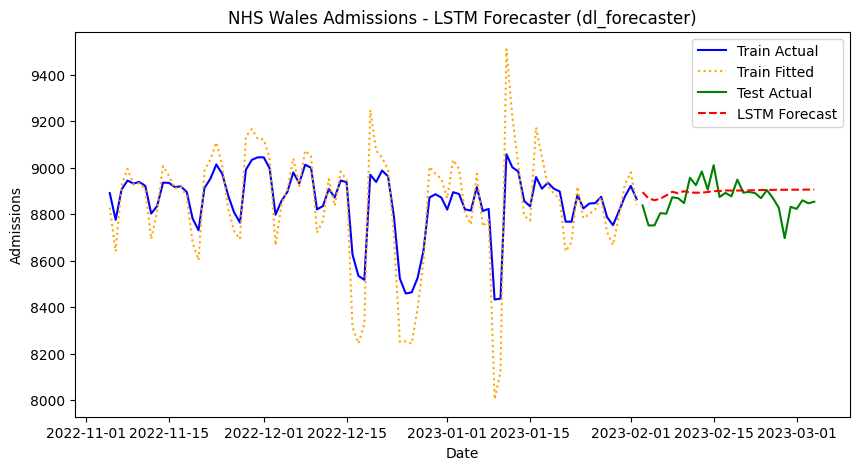

In [ ]:
#| hide
from peshbeen.metrics import WMAPE, MAE, RMSE

# Evaluate point forecast accuracy against actual hold-out test set
y_true = test['admissions'].values
wmape_val = WMAPE(y_true, forecasts)
mae_val = MAE(y_true, forecasts)
rmse_val = RMSE(y_true, forecasts)
print(f"Test Set Accuracy -> WMAPE: {wmape_val:.4f}, MAE: {mae_val:.2f}, RMSE: {rmse_val:.2f}")

# Generate in-sample fitted values
in_sample_preds = forecaster.predict_in_sample()

# Plot actual vs fitted vs forecasts
plt.figure(figsize=(10, 5))
plt.plot(train.index[-90:], train['admissions'].values[-90:], label='Train Actual', color='blue')
plt.plot(train.index[-90:], in_sample_preds[-90:], label='Train Fitted', color='orange', linestyle=':')
plt.plot(test.index, test['admissions'].values, label='Test Actual', color='green')
plt.plot(test.index, forecasts, label='LSTM Forecast', color='red', linestyle='--')
plt.title('NHS Wales Admissions - LSTM Forecaster (dl_forecaster)')
plt.xlabel('Date')
plt.ylabel('Admissions')
plt.legend()
plt.show()

In [ ]:
#| hide
# Rolling-window cross-validation test
cv_df = forecaster.cross_validate(df=train, cv_split=3, test_size=15, metrics=[WMAPE, MAE, RMSE], step_size=15)
print("Cross-Validation Evaluation Summary:")
print(forecaster.cv_summary)
assert len(forecaster.cv_summary) == 3, "Expected 3 evaluation metrics in cv_summary"

Cross-Validation Evaluation Summary:
  eval_metric  overall_score
0       WMAPE       0.012114
1         MAE     106.772526
2        RMSE     151.870569


In [ ]:
#| hide
from peshbeen.model_selection import optuna_tune

# Test optuna_tune integration with dl_forecaster
param_space = {
    "hidden_size": lambda trial: trial.suggest_categorical("hidden_size", [16, 32]),
    "lr": lambda trial: trial.suggest_float("lr", 1e-3, 5e-3, log=True),
    "lags": lambda trial: trial.suggest_categorical("lags", [2, 5])
}

best_params, best_lags, other_args, active_exog = optuna_tune(
    model=forecaster,
    df=train[-90:],
    cv_split=2,
    test_size=10,
    eval_metric=MAE,
    param_space=param_space,
    eval_num=2,
    step_size=10,
    verbose=False
)
print("Optuna tuning completed successfully for dl_forecaster:")
print("Best Hyperparameters:", best_params)
print("Best Lags:", best_lags)
assert 'hidden_size' in best_params, "hidden_size should be tuned"
assert best_lags is not None, "lags should be returned"

Optuna tuning completed successfully for dl_forecaster:
Best Hyperparameters: {'hidden_size': 32, 'lr': 0.0032481928697702905}
Best Lags: 2
